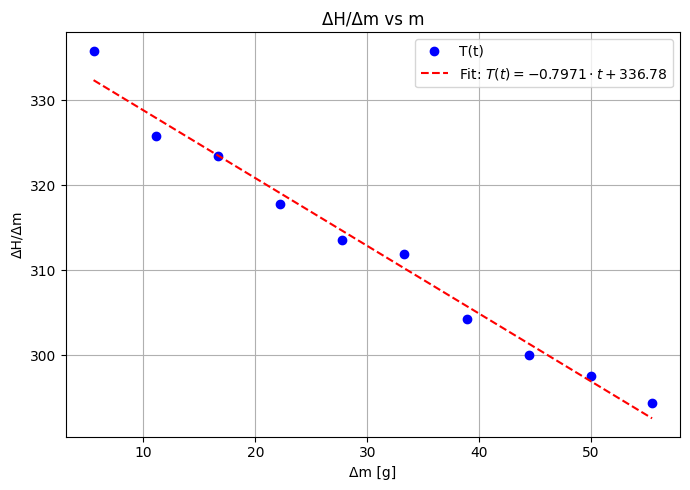

0     5.5526
1    11.0889
2    16.6640
3    22.2195
4    27.7644
5    33.3133
6    38.8708
7    44.4215
8    49.9531
9    55.4397
Name: m, dtype: float64
0    335.820248
1    325.789885
2    323.405744
3    317.796750
4    313.527673
5    311.881486
6    304.307778
7    300.023854
8    297.586676
9    294.366887
Name: delta_H/deltam, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Exp6_Kalorimetrie_Template_2025.xlsx", engine="openpyxl",
                   sheet_name="Kalorimetrie Template",
                   usecols="K,L",
                   skiprows=8,
                   nrows=10)

# ===============================
# Spaltennamen setzen und bereinigen
# ===============================
df.columns = ["m", "delta_H/deltam"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ===============================
# Lineare Regression
# ===============================
x = df["m"].values                  # Zeit auf x-Achse
y = df["delta_H/deltam"].values           # Temperatur auf y-Achse

coeffs = np.polyfit(x, y, deg=1)
fit_line = np.poly1d(coeffs)

x_fit = np.linspace(min(x), max(x), 200)
y_fit = fit_line(x_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label="T(t)")
plt.plot(x_fit, y_fit, 'r--', label=fr'Fit: $T(t) = {coeffs[0]:.4f} \cdot t + {coeffs[1]:.2f}$')

plt.xlabel("Δm [g]")
plt.ylabel("ΔH/Δm")
plt.title("ΔH/Δm vs m")

plt.ticklabel_format(axis='y', style='plain')  # Kein wissenschaftliches Format für y
plt.ticklabel_format(axis='x', style='plain')  # NEU: auch x-Achse normal formatieren
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print(df["m"])
print(df["delta_H/deltam"])

In [5]:
from scipy.stats import linregress

# Lineare Regression mit Unsicherheiten
reg_result = linregress(x, y)

steigung = reg_result.slope
achsenabschnitt = reg_result.intercept
fehler_achsenabschnitt = reg_result.intercept_stderr

print(f"Erste Lösungsenthalpie (bei m=0): {achsenabschnitt:.2f} ± {fehler_achsenabschnitt:.2f} J/mol")


Erste Lösungsenthalpie (bei m=0): 336.78 ± 1.32 J/mol


In [4]:
a = coeffs[0]
b = coeffs[1]

# Unbestimmte Integralfunktion als Textausgabe
print("\nIntegrierte Funktion (unbestimmt):")
print(f"∫f(x) dx = ({a:.4f}/2)·x² + {b:.2f}·x + C")


Integrierte Funktion (unbestimmt):
∫f(x) dx = (-0.7971/2)·x² + 336.78·x + C
